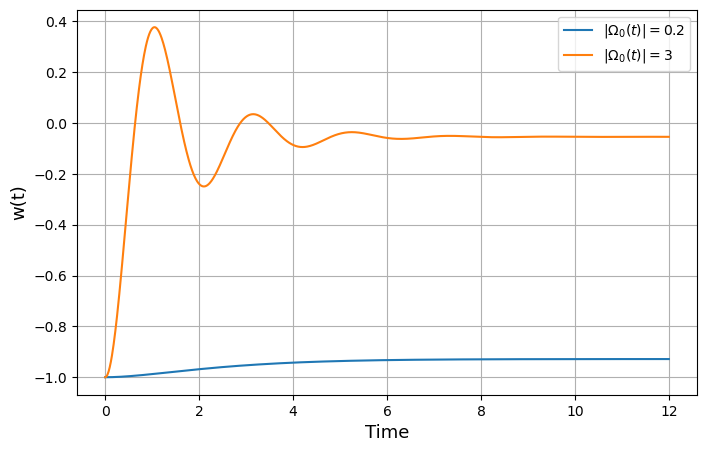

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
gamma = 0.5
gamma2 = 1.0
delta = 0.1

def bloch(t, y, Omega0):
    u, v, w = y
    du_dt = -delta * v - gamma * u
    dv_dt = delta * u - gamma * v - Omega0 * w
    dw_dt = Omega0 * v - gamma2 * (w + 1)
    return [du_dt, dv_dt, dw_dt]

# Initial state (ground state)
y0 = [0, 0, -1]

# Time span
t = (0, 12)
t_eval = np.linspace(*t, 1000)

# Case 1: Omega0 = 0.2
sol1 = solve_ivp(bloch, t, y0, args=(0.2,), t_eval=t_eval)

# Case 2: Omega0 = 3
sol2 = solve_ivp(bloch, t, y0, args=(3,), t_eval=t_eval)

# Plot w(t) for both cases
plt.figure(figsize=(8,5))
plt.plot(sol1.t, sol1.y[2], label=r'$|\Omega_0(t)|=0.2$')
plt.plot(sol2.t, sol2.y[2], label=r'$|\Omega_0(t)|=3$')
plt.xlabel('Time', fontsize=13)
plt.ylabel('w(t)', fontsize=13)
plt.legend()
plt.grid(True)
plt.show()